# Character Limits: A Technical Case Study of Reverse-Engineering and Fan-Translating Japanese Visual Novels on the Game Boy Advance

 ### Ian F.V.G. Hunter [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0003-3408-8138) 
Unaffiliated

[![cc-by](https://licensebuttons.net/l/by/4.0/88x31.png)](https://creativecommons.org/licenses/by/4.0/) 
©Ian F.V.G. Hunter. Published by De Gruyter in cooperation with the University of Luxembourg Centre for Contemporary and Digital History. This is an Open Access article distributed under the terms of the [Creative Commons Attribution License CC-BY](https://creativecommons.org/licenses/by/4.0/). Images and Audio files included in this article are not covered by this license unless indicated otherwise in a credit line. Such third-party material is included under applicable fair-use copyright exemptions and/or explicit permission from the authors.

Reverse Engineering, Translation, Game Boy Advance, GBA, ROM Hacking, Visual Novels, Digital Preservation, Fanslation, Retro Gaming, Fan Translation, Localization, Video Games

Throughout video game history, many titles have only been released regionally, whether for cultural, financial or other reasons. This paper examines the niche field of hobbyist and unofficial translation ("fanslation")through a technical case study that reverse engineers and prototypes an English localization of the Japanese visual novel "Chobits: Atashi Dake no Hito" on the Nintendo Game Boy Advance. 

Through this effort, we characterize the practical constraints on each media type (text, image, audio, video, code), such as screen-space limits for dialogue, compressed assets, propietary asset encoding and ultimiately the challenge of black-box iterpretation.

We conclude by providing pragmatic guidance on feature prioritization in a fanslation project as well as workflow recommendations both for fanslation projects themselves, as well as suggestions for improving tooling to facilitate the main goal of fanslation - unlocking games for new audiences. Collectively, our paper shows a thorough walkthrough of a ROM fanslation project and the technical barriers that shape it.

## Introduction

Nintendo's Game Boy Advance (GBA) was launched in 2001 and ceased production in 2010 <cite id="bc3sn"><a href="#zotero%7C23690838%2FJM7QDKED">(Nintendo Co., Ltd., 2024)</a></cite>. Software sales continued for 2 more years before becoming a negligible amount in Nintendo's sales <cite id="rbwqm"><a href="#zotero%7C23690838%2FPU8S75C2">(Nintendo Co., 2015)</a></cite>. Since then, there have been three further generations of game consoles, which game development companies have moved onto, with significantly more processing and graphical capabilities.

However, a small niche of development continues on the GBA. A handful of indie developers have released original games for the console well after 2012 — e.g., *"Goodboy Galaxy"* was funded on Kickstarter in 2025, promising a GBA release <cite id="p0uej"><a href="#zotero%7C23690838%2FIJCI3JAI">(Rik, 2021)</a></cite>. There is also a community of self-titled "ROM Hackers" (ROM here referring to the physical cartridges the games are stored on) who modify existing games to adapt, extend, and experiment with. 

A sub-group of these "ROM Hackers" are fan translators – or as they are more commonly known in the sphere "fanslators". Many GBA titles were released in only one language or a limited set of languages and never localised to other regions, excluding potential players. In [Table 1](#table-languages), we show the distribution of language support in the GBA games on the popular IGDB website. As can be seen, there is a sharp drop in non-English support, particularly outside Japanese and major European languages. With the discontinuation of the GBA ecosystem, most games are now unlikely to see an official new language release. By the fan translators unofficially translating these games, these games can reach a new audience. Despite the unlikelihood of official releases, GBA games are still under copyright in most jurisdictions, making much of the hobbyist work be of questionable legality. Initial legal cases such as the Nintendo vs GameGenie <cite id="eaul8"><a href="#zotero%7C23690838%2F4H2IPDGD">(U.S. Court of Appeals for the Ninth Circuit, 1992)</a></cite> "cheat cartridge" case have shown that the act of reverse engineering and modification of console code is itself not inherently illegal. Many other aspects of the law have not been tested in court, as companies typically have focussed on activities that can be seen as a perceived commercial conflict (e.g. creating separate 'level' packs for an active console was deemed an illegal derivative in the MicroStar vs FormGen case <cite id="0zdfq"><a href="#zotero%7C23690838%2FS2Q4IPIQ">(U.S. Court of Appeals for the Ninth Circuit, 1992a)</a></cite>) and companies tend to prefer issuing takedown notices over costly legal battles (Such as the takedown request of the Metroid II remake project <cite id="zbimi"><a href="#zotero%7C23690838%2FU6DWCJ4M">(Machkovech, 2016)</a></cite>).

Despite the focus on protecting active commercial interests, even during the GBA's lifetime, several bootleg copies of popular games have been sold with unofficial (and often questionable, as seen in [Figure 1](#figure-bootleg)) translations. Unlike the majority of the ROM-hacking community, which generally operates on a non-profit basis, these physical counterfeits represented a direct trademark and copyright violation that Nintendo actively pursued through coordinated seizures with government organisations. The correspondence between Nintendo and the International Intellectual Property Alliance (IIPA) <cite id="47nko"><a href="#zotero%7C23690838%2FV4EQ2TW8">(Nintendo of America Inc., 2008)</a></cite> goes into great detail about the high volume of counterfeit cartridges, difficulties with differences in IP law and enforcement of such in other countries, and a set of recommended trade monitoring actions. These cartridges often included non-modified games that were illegally manufactured.

| Language               | Total | Percentage (%) |
|------------------------|-------|----------------|
| English                | 710   | 76.84          |
| Japanese               | 326   | 35.28          |
| French                 | 97    | 10.5           |
| German                 | 97    | 10.5           |
| Spanish (Spain)        | 83    | 8.98           |
| Italian                | 80    | 8.66           |
| Dutch                  | 43    | 4.65           |
| Danish                 | 15    | 1.62           |
| Chinese (Simplified)   | 14    | 1.52           |
| Swedish                | 10    | 1.08           |
| Norwegian              | 9     | 0.97           |
| Portuguese (Portugal)  | 8     | 0.87           |
| English (UK)           | 7     | 0.76           |
| Finnish                | 6     | 0.65           |
| Portuguese (Brazil)    | 3     | 0.32           |
| Polish                 | 3     | 0.32           |
| Korean                 | 2     | 0.22           |
| Spanish (Mexico)       | 2     | 0.22           |
| Arabic                 | 1     | 0.11           |
| Chinese (Traditional)  | 1     | 0.11           |

The distribution of language data in games gathered from the IGDB website and presented in [the above Table](#languages) should be considered with additional context. As a community-maintained resource, the completeness and accuracy of data entries vary. More popular titles tend to be more comprehensively catalogued. Furthermore, the English language interface may introduce biases in the quality and quantity of contributions to English or English-translated titles, over other languages. It is also prone to contributor error. Consequently, this data should be treated as an approximate representation of language support on the GBA, rather than a definitive or objective distribution.

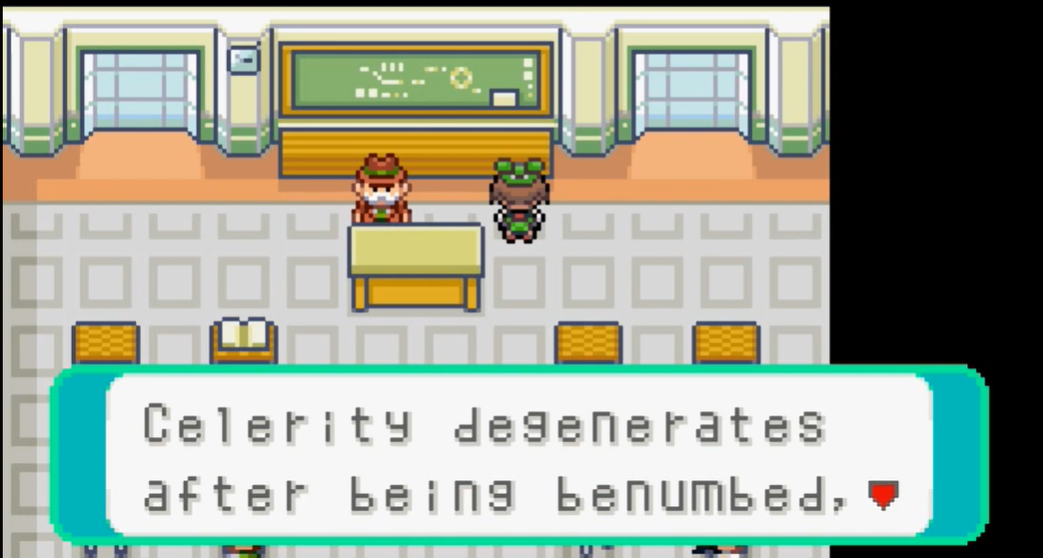

In [1]:
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Screenshot from a bootleg copy of Pokémon Emerald (A possible correct translation might read \"The 'Paralyze' effect reduces a Pokémon's speed\""
            ]
        }
    }
}
display(Image("media/bootleg.png", width=500), metadata=metadata)

Much of the existing academic literature that discusses the practice of ROM Hacking and/or fanslation is often framed around this legal context, as well as cultural and societal aspects of the practice (see, for example, <cite id="3gnbi"><a href="#zotero%7C23690838%2FNNZKYJRK">(Barnabé, 2018)</a></cite> and <cite id="ad9g5"><a href="#zotero%7C23690838%2FPT72WSJN">(Kirtz, 2018)</a></cite>). <cite id="vgofj"><a href="#zotero%7C23690838%2F7PTYDRD9">(Sánchez, 2009)</a></cite> provides a high-level overview of some technical techniques used by fan translators, but in this paper, we investigate at a deeper level through a practical case study of prototyping a reverse-engineered translation of a game, and review the challenges we faced. We review how the practice could be modernised and accelerated taking into account the last 20 years of innovation in computational advances and methodology improvements.

While we will refer to other games, this research has been performed primarily on the Japanese visual novel game "ちょびっツ for GameboyAdvance -アタシだけのヒト–", or in Roman characters – "*Chobits: Atashi Dake no Hito*" (Shortened to just "*Chobits*" for convenience for the rest of this paper). The methods in this work are independent of the actual title used.

### Background Information

The choice of *Chobits* for the case study within this paper is somewhat purposeful as it reflects both cultural and technical aspects of video game fan translation. First published as a manga in Japan in 2001 by Kodansha, *Chobits* was later translated and released in English by Tokyopop, which notes the original publication date <cite id="14wnk"><a href="#zotero%7C23690838%2FLCRQJ5I6">(CLAMP, 2002)</a></cite>, it was subsequently adapted into a 26-episode animated television series as well as three video games (the Game Boy Advance title examined in this paper, a PC game, and another on the Sony PlayStation 2) (<cite id="vecpj"><a href="#zotero%7C23690838%2FMGILIBEV">(<i>Chobits: Atashi Dake no Hito</i>, 2002)</a></cite>, <cite id="h5reu"><a href="#zotero%7C23690838%2FM44CMMKJ">(<i>Chobits: Chii Dake No Hito</i>, 2003)</a></cite>). The GBA game was released with a limited-edition GBA device ([See Figure](#package)). The game achieved commercial success in Japan and maintains cultural relevance, with the series continuing to be referenced in later media.

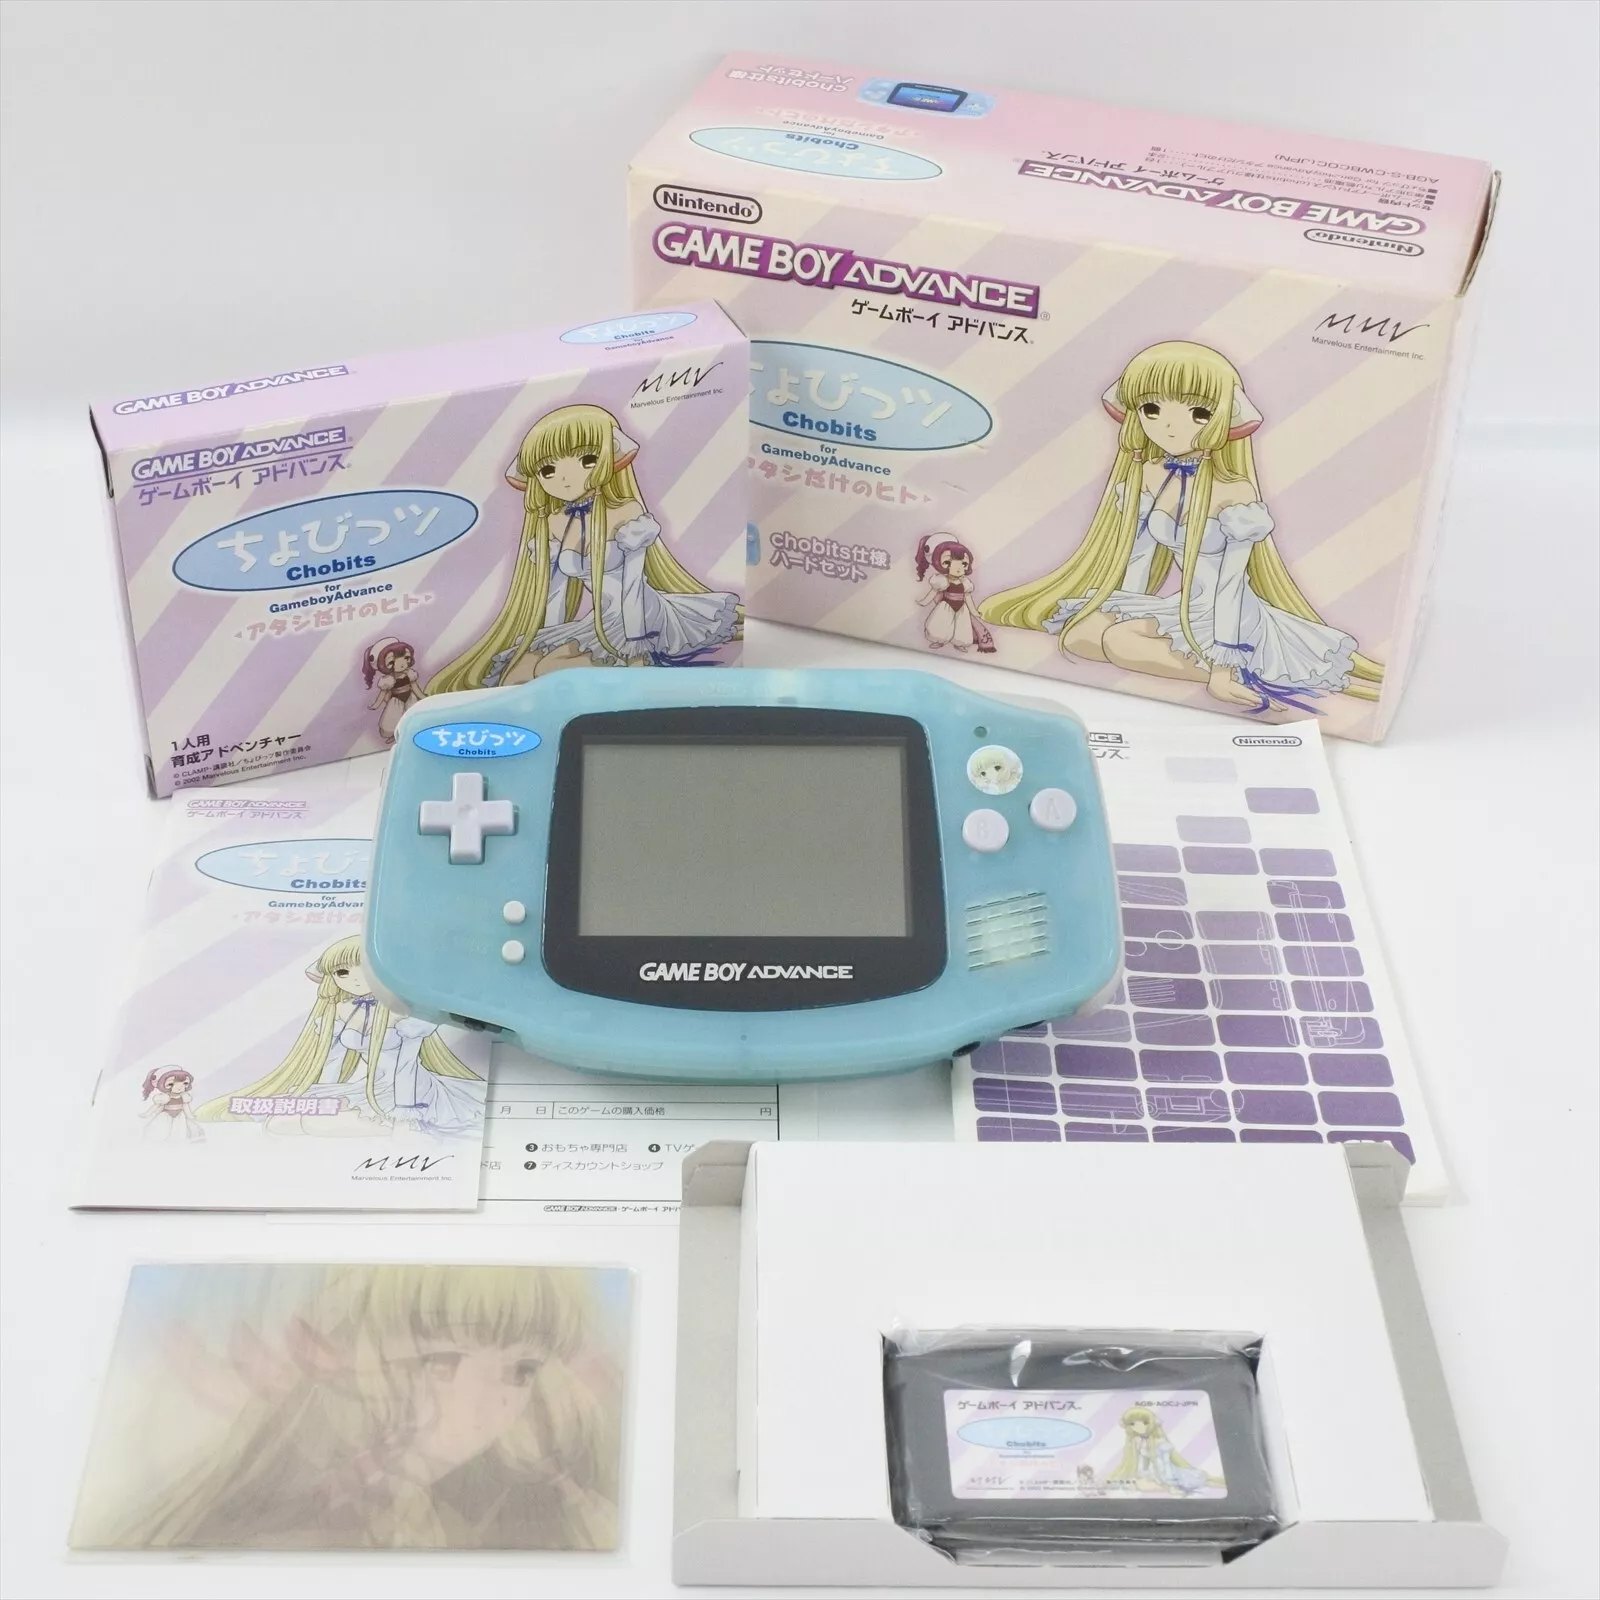

In [29]:
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "The Chobits GBA game, limited edition console and associated promotional material."
            ]
        }
    }
}
# Image reproduced with express permission from hit-japan (eBay).
display(Image("media/gba-package.png", width=500), metadata=metadata)

The series also had significant international reach — The series has been licensed in North America, Taiwan, the Netherlands, Germany, Russia, and has been broadcast on Korean, Spanish, Portuguese and Polish television networks <cite id="uo4vh"><a href="#zotero%7C23690838%2FSJ4VI5L8">(<i>Chobits (TV) - Anime News Network</i>, n.d.)</a></cite>. Recently, 20th anniversary editions of the manga were produced in Englishcho<cite id="47fsj"><a href="#zotero%7C23690838%2FY9U3PLH6">(<i>Chobits (Manga) - Anime News Network</i>, n.d.)</a></cite>. Such widespread appeal suggests that an official translation of the game would have likely found at least a niche international audience.

As a work derived from a manga title, the fanslation of *Chobits* mirrors the efforts of fanslators for decades, well before the GBA was even released. Since the 1980s, anime and manga have had a strong fan culture of sharing inaccessible media in the absence of licensing or localisation companies<cite id="g5rgd"><a href="#zotero%7C23690838%2FWNUGKPCI">(Hatcher, 2005)</a></cite>. Tremblay argues that these sorts of efforts have created stronger interest in media and the genre as a whole, along with strengthened consumer investment into future products, much like how the Japanese doujinshi (unauthorised fan comics) are actively encouraged by their media's owners as it is seen as symbiotic rather than competitive <cite id="4j2ub"><a href="#zotero%7C23690838%2FDHDTN65W">(Tremblay, 2018)</a></cite>. Indeed, several companies in media distribution have been created from systems such as these. A well-known example is Crunchyroll, now the largest dedicated anime streaming service, which was originally a fan-subtitle aggregation website before transitioning into a licensed platform <cite id="83jzg"><a href="#zotero%7C23690838%2FLMHMAPSC">(Loo, 2008)</a></cite>. Another notable example is Manga Rock, a frontend for several illegal manga-hosting websites which transitioned into an official platform for manga, manwha and webtoons <cite id="nja2p"><a href="#zotero%7C23690838%2FNEKBFI45">(Mateo, 2020)</a></cite>. 

As noted in the [Introduction](#introduction), existing academic work is predominantly concerned with these interesting legal and cultural scenarios, rather than the technical process of translation. As a visual novel, *Chobits* is a title with a lot of textual and visual content, which can be difficult to fit within the limited confines of the GBA device. Its translation is crucial to the accessibility of the media, unlike other titles, where the enjoyment stems from active gameplay mechanics (like platformers) which one can reasonably enjoy without translation. Unlike anime or manga translation, which requires translation skills and some level of competency with image editing and subtitling software, translating this game perfectly would require an advanced programming skillset with an ability to reverse engineer and understand embedded devices. This high barrier to entry has likely limited the number of complete fanslations released each year. In [the Figure below](#releases), a timeline of final releases of GBA games is shown, gathered from the romhacking.net community. The increase in releases from 2019 to 2022 coincides with COVID-19 movement restrictions, which likely contributed to increased participation in home-based hobbies, such as GBA fanslation.

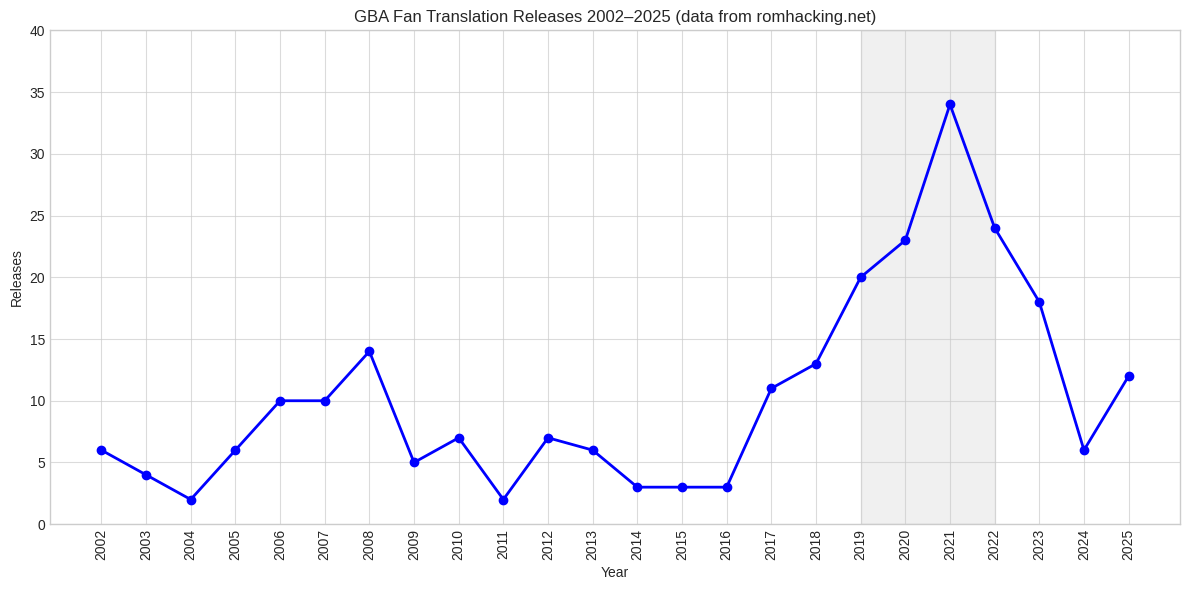

In [37]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

filename = "media/gba_fanslation_releases_2002_2025.csv"

with open(filename) as f:
    reader = csv.DictReader(f)
    data = [(int(r["year"]), int(r["releases"])) for r in reader]

years, releases = zip(*data)

# 2. Create the plot
plt.figure(figsize=(12, 6))
plt.plot(years, releases, color='blue', marker='o', linewidth=2, markersize=6)

# 3. labels
plt.xlabel('Year')
plt.ylabel('Releases')
plt.title('GBA Fan Translation Releases 2002–2025 (data from romhacking.net)')

# Set axis limits and ticks
plt.ylim(0, 40)
plt.xticks(years, rotation=90)
plt.grid(True, linestyle='-', alpha=0.7)

# Hilight time range of COVID-19
plt.axvspan(2019, 2023, color='black', alpha=0.06, zorder=0)

# 4. Display
plt.tight_layout()
plt.show()

### Game Boy Advance

Nintendo's Game Boy Advance, while being a video game console, is also a resource-constrained embedded system. The main processor is a 32-bit ARM7TDMI. It possesses 32 KB of on-chip RAM, 256KB of external RAM and has a cartridge based ROM space typically between 4 and 32 MB (64MB cartridges did exist, but were rare and exclusively used for feature-length films for Game Boy Advance Video. These cartridges included a bank-switcher on the cartridge to get around the 32MB limitation). The *Chobits* game cartridge is 8MB. Historically, production costs for a game would increase with ROM capacity, which would impact profits for the game company, so smaller cartridges and space-saving programming techniques were often incentivised. The THQ Inc 2004 10-K filing mentions Nintendo's manufacturing fees varied with size <cite id="2t6qa"><a href="#zotero%7C23690838%2FGUPI8NSD">(THQ Inc., 2004)</a></cite>.

The system provides memory-mapped graphics, audio, and input peripherals and executes software directly on the hardware without an operating system. Background images are tilemaps and movable objects use sprites; both are built from tiles stored in limited VRAM and indexed through small colour palettes, while audio is controlled through two sound engines via Direct Memory Access (DMA). The device relies on hardware timers and interrupts to manage operations such as rendering and input handling.

Nintendo has not officially released its internal GBA programming manual, however several online community guides exist such as the ones at the <cite id="lrg0g"><a href="#zotero%7C23690838%2FSSTELK5C">(GBAdev.net community, 2025)</a></cite> and <cite id="wozhd"><a href="#zotero%7C23690838%2F4SIVM7J7">(GBATEK/mGBA community, 2025)</a></cite> websites which detail the system architecture, including memory maps, I/O registers, timers, interrupts, graphics and audio subsystems as well as how to interact and program them.

Several pieces of community software are available to the hobbyist fanslator such as coding libraries, hex editors, tile viewers and script parsers. Despite these shared resources, individual games may provide unique technical challenges (as we will explore later in the Methodology Section below), such that even with these tools, many aspects are dependent on manual investigation and trial-and-error techniques.

# Methodology

This study was conducted using a legally obtained retail copy of the *Chobits* GBA game cartridge. The contents of the cartridge were extracted using commercially available cartridge "dumping" hardware. The resulting binary file represents a bitwise copy of the original game stored on the cartridge. Cartridges are generally read-only and aftermarket cartridges which allow writing of the ROM are one of the only methods that exist as a possible avenue to playing modified games on the original hardware. For the purposes of our study, using a GBA emulator was sufficient.

## Text Translation

In keeping with its name, games in the "Visual Novel" genre contains a lot of text. In English, text strings on the GBA are often straightforward arrays of single-byte ASCII characters with null character termination. However, in order to accomodate a reasonably operable collection of hiragana, katakana and kanji characters required for Japanese, developers will often need to use a two-byte encoding such as SHIFT-JIS. 

We were able to identify game text in our target game by doing a brute-force search for pointers in the code which resolved to byte sequences which were null-terminated within a reasonable amount of characters (we generously gave a 256 charcacter lookahead). By placing these candidate strings in an editor with the ability to switch between text encodings, we established that two encodings were being used. A half-width and a full-width SHIFT-JIS encoding. The former uses a narrow font for more compact text regions, with predominantly using roman characters, hiragana and katakana, and the latter for full size in-game text with a wide range of kanji available for use.

Game developers did not always adhere to the official specifications of formats, and excluded unused characters or rearranged them for better memory utilisation. If a standard encoding has not been used, fan translators often create what they have termed as a "Table File" (.TBL) which is a simple key-value mapping to be used in place of a usual text encode/decoder. In our study, we found that the Roman characters were relocated within the traditional SHIFT-JIS layout, and so we had to perform a similar remapping operation. A second pass of scanning the ROM's pointers, now eliminating strings containing unusual character codes (e.g. the ENQ character in ASCII (Often used for communication protocols rather than traditional textual content)) in the encodings were eliminated, providing a much smaller candidate list.

While efforts have been made to create sensible pattern matching for game text, preferring to permit false positives than to discard false negatives, the final strings for user translation still require interpretation. Some byte patterns that may be artefacts of other media (code, images, etc) may provide 'valid' strings such as single kanji which may be valid or not, or nonsensical combinations e.g. "汪穀漠" which, despite consisting of apparantly well-formed encoded characters, does not correspond to any meaningful Japanese text.

As <cite id="35edf"><a href="#zotero%7C23690838%2FTAS4LDM9">(Nida, 1964)</a></cite> describes, translating text often requires careful judgement on the translator's behalf in order to keep both the formal (literal) and dynamic (sense/meaning) equivalence of the text intact. Technical and practical limitations restrict the translator even more so in this respect. While technically the game could be translated at this point by direct replacement of the strings in memory, the flexibility a translator has is greatly diminished. Even a simple "Yes" may be forced to become an unnatural "Ya" when the affirmative "はい" is the only text before null termination. Whilst a translator could put in an oversized string and still terminate it, it will corrupt the following data. An interactive worked example is given in [the Figure below](#overwriting).

Because of this, it is common to invoke a memory manager application which will reorganise the pointers in the code. In our example, we were able to use empty space at the end of the ROM file to store our strings, as well as re-using the allocated memory from the existing Japanese strings. This increases the flexibility of translators, but does not entirely eliminate it, for there remain two distinct constraints: The unallocated ROM size and the visual space given to the text. 

In [90]:
import html
import ipywidgets as widgets
from IPython.display import display, HTML

JP_A = "『ちぃ』しか言えないんだ"
EN_A = "Hmm.. Perhaps, is 'Chi' the only thing she can say?"
JP_B = "ちぃ!!"  # 8 bytes in UTF-8
EN_B = "Chii!!"  # 6 bytes

JP_A_BYTES = JP_A.encode()
JP_B_BYTES = JP_B.encode()
OFF_B = len(JP_A_BYTES)


def utf8_len(b):
    if b < 0x80:
        return 1
    if (b & 0xE0) == 0xC0:
        return 2
    if (b & 0xF0) == 0xE0:
        return 3
    if (b & 0xF8) == 0xF0:
        return 4
    return 0


def render_compact_view(write_a_len, write_b_len, english_order):
    mem = bytearray(64)
    mem[: len(JP_A_BYTES)] = JP_A_BYTES
    mem[OFF_B : OFF_B + len(JP_B_BYTES)] = JP_B_BYTES

    ea = EN_A.encode()[:write_a_len]
    eb = EN_B.encode()[:write_b_len]
    a_first = english_order == "A then B"

    def write_a():
        mem[: len(ea)] = ea
        if write_a_len:
            mem[len(ea)] = 0

    def write_b():
        mem[OFF_B : OFF_B + len(eb)] = eb
        if write_b_len:
            mem[OFF_B + len(eb)] = 0

    for fn in ((write_a, write_b) if a_first else (write_b, write_a)):
        fn()

    def string_at(mem, start):
        """C-style string: bytes from start until NUL or end of buffer."""
        end = start
        while end < len(mem) and mem[end] != 0:
            end += 1
        return mem[start:end].decode("utf-8", errors="replace")

    def dot_color(i):
        if i < write_a_len and OFF_B <= i < OFF_B + write_b_len:
            return "#81C784" if not a_first else "#DCE775"
        if i < write_a_len:
            return "#81C784"
        if OFF_B <= i < OFF_B + write_b_len:
            return "#DCE775"
        return "#FF8A65" if i >= OFF_B else "#4FC3F7"

    def span(color, inner, width_ch=2):
        return (
            f'<span style="color:{color};display:inline-block;width:{width_ch}ch;'
            f'text-align:center;font-size:0.82em;line-height:1.15">{inner}</span>'
        )

    hex_row = eng_row = ""
    jis_row = []

    for i in range(64):
        b = mem[i]
        fg = "#444" if b == 0 else dot_color(i)

        hex_row += span(fg, f"{b:02X}")
        eng_row += span(fg, chr(b) if 32 <= b <= 126 else ".")

        in_ascii = i < write_a_len or OFF_B <= i < OFF_B + write_b_len
        if in_ascii:
            jis_row.append(span(fg, chr(b) if 32 <= b <= 126 else "&nbsp;"))
        elif (b & 0xC0) == 0x80:
            jis_row.append('<span style="display:inline-block;width:2ch;font-size:0.82em"></span>')
        elif b == 0:
            jis_row.append(
                '<span style="color:#444;width:2ch;display:inline-block;text-align:center;font-size:0.82em">&nbsp;</span>'
            )
        else:
            n = utf8_len(b)
            chunk = mem[i : i + n] if n and i + n <= 64 else None
            if chunk:
                try:
                    ch = chunk.decode("utf-8")
                    ok = len(ch) == 1
                except UnicodeDecodeError:
                    ok = False
            else:
                ok = False
            if ok:
                jis_row.append(span(fg, ch, n * 2))
            else:
                jis_row.append(
                    '<span style="color:#f44336;width:2ch;display:inline-block;text-align:center;font-size:0.82em">?</span>'
                )

    legend = (
        '<div style="margin-top:16px;font-size:0.85em;border-left:3px solid #f44336;padding-left:10px">'
        '<span style="color:#4FC3F7">JP string A</span> · '
        '<span style="color:#81C784">English A</span> · '
        '<span style="color:#FF8A65">JP string B</span> · '
        '<span style="color:#DCE775">English B</span>'
        "</div>"
    )

    str_a = string_at(mem, 0)
    str_b = string_at(mem, OFF_B)
    live_strings = (
        '<div style="margin-top:12px;font-size:0.88em;line-height:1.4;color:#ddd;'
        'white-space:normal;overflow-wrap:anywhere;border-left:3px solid #546E7A;padding-left:10px">'
        '<div style="margin-bottom:6px"><b style="color:#888">String A:</b> '
        f'<span style="color:#eceff1">{html.escape(str_a)}</span></div>'
        '<div><b style="color:#888">String B:</b> '
        f'<span style="color:#eceff1">{html.escape(str_b)}</span></div>'
        "</div>"
    )

    figure_html = (
        '<div style="background:#0a0a0a;padding:16px;font-family:Courier New,Consolas,monospace;'
        'border-radius:5px;white-space:nowrap;overflow-x:auto">'
        f'<div style="margin-bottom:6px"><b style="color:#666;width:44px;display:inline-block">HEX:</b>{hex_row}</div>'
        f'<div style="margin-bottom:6px"><b style="color:#666;width:44px;display:inline-block">JIS:</b>{"".join(jis_row)}</div>'
        f'<div style="margin-bottom:6px"><b style="color:#666;width:44px;display:inline-block">ENG:</b>{eng_row}</div>'
        f"{legend}{live_strings}</div>"
    )

    display(
        HTML(figure_html),
        metadata={
            "jdh": {
                "module": "object",
                "object": {
                    "type": "image",
                    "source": [
                        "An example of how overfilling strings cannot work without modifying the associated pointers."
                    ],
                },
            },
        },
    )


widgets.interact(
    render_compact_view,
    write_a_len=widgets.IntSlider(
        min=0,
        max=len(EN_A),
        value=0,
        description="# of A's translation to write:",
        style=widgets.SliderStyle(description_width="280px"),
        layout=widgets.Layout(width="500px"),
    ),
    write_b_len=widgets.IntSlider(
        min=0,
        max=len(EN_B),
        value=0,
        description="# of B's translation to write:",
        style=widgets.SliderStyle(description_width="280px"),
        layout=widgets.Layout(width="500px"),
    ),
    english_order=widgets.ToggleButtons(
        options=["A then B", "B then A"],
        value="B then A",
        description="Translation Write Order:",
        tooltips=[
            "Write EN-A into memory first, then EN-B (B wins overlaps)",
            "Write EN-B first, then EN-A (A wins overlaps)",
        ],
        style=widgets.ToggleButtonsStyle(description_width="180px"),
        layout=widgets.Layout(width="100%"),
    ),
);

interactive(children=(IntSlider(value=0, description="# of A's translation to write:", layout=Layout(width='50…

Playing with this example, you should see that data corruption is a tangible risk for a naïve string replacement. You may be able to find a translation that fits the same memory bounds, but it limits the translation's flexibility. Using the "A then B / B then A" tabbed buttons, you can see that the order in which you apply the replacements also changes how the data is corrupted when the strings overlap. This example uses basic UTF-8 encoding to demonstrate the concept, but in *Chobits* the Japanese is encoded in SHIFT-JIS so the exact hex values, byte counts and such are for illustration only.

Expanding the ROM size is straightforward. The cartridge sizes for the GBA increment in powers of two (i.e. 4MB, 8MB, 16MB and 32MB). To expand to the next size, simply pad the end of the ROM to that boundary. The addressing space of the ROM is 0x08000000—0x09FFFFFF so 32MB is the practical limit of size for ROM translators and generally sufficient for that purpose. For more involved fan works which expand the scope of existing media, it is possible to implement software-controlled ROM paging to use a larger cartridge. Due to its complexity of implementation, this technique is not often used and of course, cannot fit on a standard physical retail cartridge. The vGBA-m recently added support for ROM sizes up to 128MB for games that implement this software paging, but many other emulators do not support such ROMs <cite id="gkdeu"><a href="#zotero%7C23690838%2F9YYDH3PY">(Team, 2025)</a></cite>.

In *Chobits*, much of the dialogue is in the same location throughout the game — at the bottom of the screen. This area can fit up to 32 characters split over two rows. Even if we have the memory space to write a long and accurate translation, it may not fit in the text box and run off-screen. This area was restricted by the display code to the 2-byte SHIFT-JIS variant encoding mentioned before, so we unfortunately could not save space by using the smaller encoding. The difference in character width can be see in [the Figure below](#fig_screen1) which also shows the dialogue text box. Sometimes dialogue will continue on a gamepad button press and a refresh of the textbox, but while other visual novel games implement this "page turn" by checking for a special reserved character in the encoding set, it seemed that each page of this game was programmed manually, so we worked within these limits for the sake of reduced complexity.

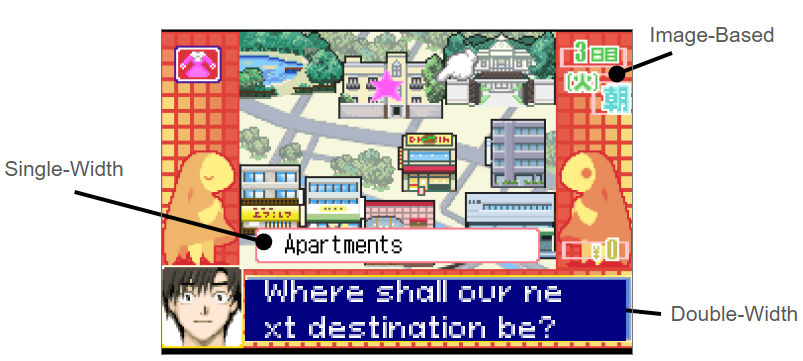

In [8]:
import os
from pathlib import Path

from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
from IPython.display import Image as NormalImage

img_path = "media/text_types.png"


def load_overlay_font(size: int = 40):
    try:
        return ImageFont.truetype("media/PixeloidSans-lxa3y.ttf", size)
    except OSError:
        return ImageFont.load_default()


def wrap_fixed_chars(text: str, chars_per_line: int = 11) -> str:
    """Hard-wrap so each line has at most ``chars_per_line`` characters."""
    return "\n".join(text[i : i + chars_per_line] for i in range(0, len(text), chars_per_line))


def render_text_overlay(
    text,
    x=245,
    y=280,
    box_w=380,
    box_h=60,
    chars_per_line=18,
    font_size=29,
    pixel_scale=2,
):
    """Draw with a monospace font. ``pixel_scale`` > 1 draws smaller then NEAREST-upscales for a chunky look."""
    img = Image.open(img_path).convert("RGBA")
    draw = ImageDraw.Draw(img)

    wrapped = wrap_fixed_chars(text, chars_per_line)
    scale = max(1, int(pixel_scale))
    small = max(8, font_size // scale)
    font = load_overlay_font(small)

    scratch = Image.new("RGBA", (1, 1))
    scratch_draw = ImageDraw.Draw(scratch)
    bbox = scratch_draw.textbbox((0, 0), wrapped, font=font)
    x_offset = 10
    ox, oy = bbox[0] - x_offset, bbox[1]
    tw = int(bbox[2] - bbox[0]) + x_offset
    th = int(bbox[3] - bbox[1])

    layer = Image.new("RGBA", (max(1, tw), max(1, th)), (0, 0, 0, 0))
    layer_draw = ImageDraw.Draw(layer)
    layer_draw.text((-ox, -oy), wrapped, fill="white", font=font)

    if scale > 1:
        layer = layer.resize(
            (layer.width * scale, layer.height * scale),
            resample=Image.NEAREST,
        )

    text_w, text_h = layer.size
    fits = text_w <= box_w and text_h <= box_h

    box_color = "navy"
    draw.rectangle([x, y, x + box_w, y + box_h], outline=box_color, fill=box_color, width=2)
    img.paste(layer, (x, y), layer)

    return img, fits

metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "An example of how overfilling strings cannot work without modifying the associated pointers."
            ]
        }
    }
}

INTERACTIVE = True
if INTERACTIVE:
    img, fits = render_text_overlay("Where shall our next destination be?")
    display(img, metadata=metadata)
else:
    display(NormalImage(img_path), metadata=metadata)


Although these methods may alleviate the size limitations on the game's text content, It may be favourable for the overall experience of the game to trade accuracy in translations for visual cohesion. For example, if the dialogue in [the figure above](#text-replace) was translated more correctly as "Where will we travel to?" this would be 24 characters, and automatic line-breaking would result in "Where will we t" on one line, and "ravel to?", giving an unprofessional look to the dialogue.

In [ ]:
HERMENETICS ABOUT CODE

## Image Translation

As can be seen in [the earlier Figure](#figure_screen1), not all text in a game may be textual. (火) here is shorthand for "火曜日" or Tuesday, 朝 means "morning" and "日目" is "day". Rather than being found in our SHIFT-JIS or ASCII text encodings, they are built from image sprites in the ROM memory and tiled onscreen. The main game dialogue, map placenames and text within the mini-games were all translatable with text-based strings, and many fan translators would consider this enough to release the game. For a polished end product, these secondary display components, logos and title screens can elevate a game to a similar grade as a professional effort.

Akin to the encoding issue before, there are several formats that image data can take on the device, including compressed formats. The most common uncompressed representation of this image data is in multiple 8x8 pixel tiles with 4 and 8 bit indices into a colour palette, stored separately. The GBA BIOS provides a target-specific implementation of the LZ77 compression algorithm, as well as Huffman and Run-Length Encoding variants. Game developers may also implement their own compression schemes or encodings which are decompressed at run-time.

A selection of Chobits tiles, with a randomised colour palette, are shown in [our Figure below](#sprite-view), as seen from the YY-CHR tool<cite id="kaxbp"><a href="#zotero%7C23690838%2F69IPZCCX">(YY, 2012)</a></cite>. As can be seen, some of the full sprites are disjoint in memory, sprites have various "widths" that differ to, or align with, the viewer's window size, causing some of them to horizontally "tear", some tiles also seem out-of-order. Both the diversity of image formats, as well as the various unique aspects of each sprite meant that extracting the sprites into an orderly folder of images was difficult. Instead, we extracted each candidate tile individually and used a script to stitch them together for editing. The image editing itself is not foolproof either — compressed image data must compress to the same or greater amount in order to fit in the same memory location without overwriting adjacent data, the images separate palettes can be difficult to trace and if modified, can cause unexpected colour alterations in other sprites using the same palette.

While our ROM analysis successfully identified much of the *Chobits* sprite data, many assets, particularly at the beginning of the game, remained elusive. For example, the HUD confirmation icons ("はい/いいえ" or "Yes/No") were found in several locations, but transpired to be orphaned or redundant data, where altering them had no visible effect in-game. This suggests to us that some non-trivial system was controlling these sprites, perhaps a proprietary encoding, undocumented compression algorithm or programmatic composition. During the investigation of these assets we applied Corruption Mapping (also called Pattern Injection) on the visually identified "sprite" sections of the ROM and utilized various emulator runtime inspectors to monitor VRAM during the display of the assets to screen. The persistence of these icons to remain unmodified despite these interventions, suggests a implementation more sophisticated than the encodings traditionally used in contemporary GBA titles.

Corruption mapping (a.k.a. Pattern Injection) is a technique we used throughout the investigation of this GBA title. By "corrupting" a region of memory with a known value (e.g. 0xFF), we can visually correlate that change with their on-screen manifestations. For example, a tile may disappear, or audio might corrupt. This technique requires a careful approach and rough knowledge of the asset layout in the ROM as corrupting a code section may cause unexpected behavior including misleading visual glitches.

--- Default View ---


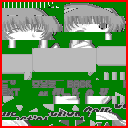

--- NPC Face ---


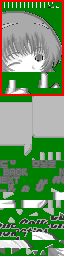

--- Pointing Finger ---


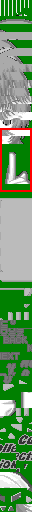

--- UI Text (with Stride) ---


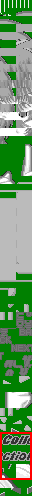

In [9]:
from PIL import Image as PILImage, ImageDraw as PILImageDraw
from IPython.display import display
import os

class SpriteReassembler:
    TILE_DIM = 8 # 8x8 GBA Tiles are the smallest sprite unit because of the BG & OBJ hardware

    def __init__(self, image_path):
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Could not find image at {image_path}")
        self.src_img = PILImage.open(image_path).convert("RGBA")

    def _get_flattened_tiles(self, offset=0):
        """Extracts all tiles into a flat list."""
        sw, sh = self.src_img.size
        tiles = []
        for y in range(0, sh, self.TILE_DIM):
            for x in range(0, sw, self.TILE_DIM):
                tiles.append(self.src_img.crop((x, y, x + self.TILE_DIM, y + self.TILE_DIM)))
        return tiles[offset:]

    def reassemble(self, sprite_w, sprite_h, stride=None, tile_offset=0, hl_start=None, hl_count=1):
        """
        Reassembles tiles into sprites and applies highlighting.
        Assumes the original image is not under any existing layout 
        (The YY-CHR default)
        """
        stride = stride or sprite_w
        tiles = self._get_flattened_tiles(tile_offset)
        
        # Geometry Calculations
        tiles_per_strip = stride * sprite_h
        num_strips = len(tiles) // tiles_per_strip
        sprites_per_row = stride // sprite_w
        total_sprites = num_strips * sprites_per_row

        if total_sprites == 0:
            return None

        # Create Canvas
        canvas_w = sprite_w * self.TILE_DIM
        canvas_h = total_sprites * sprite_h * self.TILE_DIM
        new_img = PILImage.new("RGBA", (canvas_w, canvas_h), (0, 0, 0, 255))
        draw = PILImageDraw.Draw(new_img)

        # Re-assembly
        for i in range(total_sprites):
            # Map sprite index back to tile grid
            strip_idx = i // sprites_per_row
            s_x = i % sprites_per_row
            base_tile_idx = (strip_idx * tiles_per_strip) + (s_x * sprite_w)

            for ty in range(sprite_h):
                for tx in range(sprite_w):
                    tile_idx = base_tile_idx + (ty * stride) + tx
                    if tile_idx < len(tiles):
                        dx = tx * self.TILE_DIM
                        dy = (i * sprite_h + ty) * self.TILE_DIM
                        new_img.paste(tiles[tile_idx], (dx, dy))

        # Apply Highlight Box
        if hl_start is not None:
            self._draw_highlight(draw, hl_start, hl_count, sprite_w, sprite_h)

        return new_img

    def _draw_highlight(self, draw, start, count, s_w, s_h):
        """
        Draws a red selection box around specified sprite range.
        This is not pixel-perfect and is only for drawing the reader's eye.
        To make it pixel perfect, you would need to add pixel offsets (as opposed to tile offsets)
        to the configs, making the code further complicated.
        """
        y_start = start * s_h * self.TILE_DIM
        y_end = (start + count) * s_h * self.TILE_DIM - 1
        x_end = (s_w * self.TILE_DIM) - 1
        draw.rectangle([0, y_start, x_end, y_end], outline="red", width=2)


# --- Interactive Configuration ---
configs = {
    "Default View":          {"sprite_w": 16, "sprite_h": 16, "hl_start": 0,  "hl_count": 1},
    "NPC Face":              {"sprite_w": 8,  "sprite_h": 4,  "hl_start": 0,  "hl_count": 3},
    "Pointing Finger":       {"sprite_w": 4,  "sprite_h": 4,  "hl_start": 4,  "hl_count": 2},
    "UI Text 'Collection' (with Stride)": {"sprite_w": 4,  "sprite_h": 2,  "stride": 4, "tile_offset": 2, "hl_start": 27, "hl_count": 3}
}

assembler = SpriteReassembler("media/CHR000_normal.bmp")
    
for label, params in configs.items():
    print(f"--- {label} ---")
    img = assembler.reassemble(**params)
    if img:
        display(img)
    else:
        print("Failed to generate image. Check dimensions.")

In the code above, we have taken a snapshot of the GBA ROM memory from YY-CHR and view it in different layouts to understand the sprite dimensionality. In the first output image, which is the YY-CHR default view, it is clear there are some images of interest present. By experimenting with various sprite sizes, offsets and strides, we can decypher the original images. We present three different configurations in this example — a NPC face, a pointing finger and a piece of UI text. You may wish to experiment and see if you can reconstruct the speech bubble sprite that is also present.

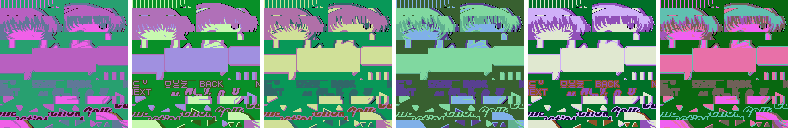

In [40]:
from PIL import Image as PILImage
from IPython.display import display
import random

class GBAPaletteSwapper:
    def __init__(self, image_path):
        self.src_img = PILImage.open(image_path).convert("RGB")

    def _palette_template_16(self, colors16):
        """Build a Pillow palette image from exactly 16 RGB colours."""
        flat = [c for (r, g, b) in colors16 for c in (r, g, b)]  # 16*3 = 48
        flat += flat[-3:] * (256 - 16)  # pad to 256 colours

        pal = PILImage.new("P", (1, 1))
        pal.putpalette(flat)
        return pal

    def swap(self, colors16):
        """Quantize to the given 16‑colour palette (no dithering)."""
        pal = self._palette_template_16(colors16)
        return self.src_img.quantize(palette=pal, dither=0).convert("RGBA")

    def random_palette_16(self):
        """Random 16‑colour palette."""
        colors = [(0, 0, 0)]  # force index 0 to black/transparent
        while len(colors) < 16:
            colors.append((
                random.randint(0, 31) << 3,
                random.randint(0, 31) << 3,
                random.randint(0, 31) << 3,
            ))
        return colors

    def show_random_variants(self, n=6, padding=4):
        variants = [self.swap(self.random_palette_16()) for _ in range(n)]

        w, h = self.src_img.size
        canvas = PILImage.new("RGBA", ((w * n) + (padding * (n - 1)), h), (0, 0, 0, 0))
        for i, img in enumerate(variants):
            canvas.paste(img, (i * (w + padding), 0))

        display(canvas)

# --- Execution ---
img_path = "media/CHR000_normal.bmp"

lab = GBAPaletteSwapper(img_path)
lab.show_random_variants(n=6)

While running on the device each sprite is associated with a palette which defines the colours it will use. This palette for one sprite is limited to 16 colours. 16 palettes can be loaded in at one time in Palette Ram (PALRAM) allowing sprites on the same screen to have different colours to each other. Palettes are not necessarily located close to the sprites themselves, and so, without the ability to detect them, many tools will use a random palette selection in its absence (like those generated above). Each time you run this script, it will generate new colour assignments.

The aesthetic quality of palette swapping has inspired much online art and echoes earlier experimental works such as Andy Warhol's Marilyn Diptych <cite id="on4ik"><a href="#zotero%7C23690838%2FJ6VS4TBW">(Warhol, 1962)</a></cite>, where the same image is reused with different colour treatments to create impactful visual variation. 

In lieu of these assets, we performed a comparative analysis on another visual novel by the same development company — "ラブひなアドバンス 祝福の鐘はなるかな"(often translated as "*Love Hina Advance: The Blessing Bell*"), in which the approach to storing sprites is more typical of GBA games. While much of the *Chobits* starting screens are video-based, *Love Hina* game is largely sprite based and the title display was much easier to visually locate than the small dialogue buttons. *Love Hina* was released approximately 1 year before *Chobits* suggesting that the difficulty in viewing sprites may have been a maturation of the development process. As the team became more familiar with the device and its operation, they may have moved away from the standard storage mechanisms to improve memory management, data compression, etc.

After locating the tile images, we performed the same extraction-modification-reinsertion procedure as before, and when we reloaded the game, the modified image appeared — as shown in [the figure below](#comparelogo). Disregarding the author's artistic ability (or lack thereof) to replicate a title screen as impactfully as the original, the primary reason for the limited artistic expression of the display is due to the difficulty of aligning pixels between tiles, which had to be done via pixel counting. In some areas we were able to take larger "chunks" of the overall image at once, which made things simpler, but other areas had to be manually aligned. For a professional finish, it is likely that one would have to create a bespoke mapping and extraction suite to improve the freedom of the artist translating the tiles.

In [11]:
from IPython.display import display, HTML

meta = {
    "jdh": {
        "module": "object",
        "object": {
            "type": "image",
            "source": ["Replacing the game title via sprite modification."]
        }
    }
}

# side-by-side layout using HTML table
display(HTML(f"""
<div style="display: flex; justify-content: center; align-items: center;">
    <div style="margin: 5px;">
        <img src="media/love_hina_logo_original.png" width="450">
        <p style="text-align: center;">Original</p>
    </div>
    <div style="margin: 5px;">
        <img src="media/love_hina_logo_new.png" width="450">
        <p style="text-align: center;">Translated</p>
    </div>
</div>
"""), metadata=meta)



## Video/Audio Translation

Most fan translation efforts stop at text and image translation as this covers the majority of content changes required for enjoyment of a game. However, for completeness, we will comment briefly on the remaining aspects.

Video was often performed with bespoke compression codecs, though later GBA titles often used the proprietary Mobiclip format by Actimagine<cite id="lirkd"><a href="#zotero%7C23690838%2F44B6EBPF">(Actimagine, 2006)</a></cite>. The complexity of decoding these is much higher than that of text or image data, and it also suffers from the compression problem mentioned earlier — where translating the media can inflate the file size, making it overflow the original allocations. Using the debugging tools available in mGBA and inspecting the sprites on-screen, it appears that the videos in *Chobits* and *Love Hina* rapidly update the foreground with a range of predefined sprites, which appear standalone to be simply noise or scrambled fragments (Part of the complication here is the added fact that sprites can be transparent, meaning that the images shown onscreen may be composites of several sprites), but when correctly indexed and streamed at the device frequency, they form a cohesive moving image. 

The retrieval of these tiles is a system that is highly opaque; without access to the original tools, code or documentation, the effort to translate these components is much higher than the payoff for doing so.

Similar to video, audio is technically difficult to reverse engineer and modify. The GBA lacks a dedicated audio synthesizer chip and instead operates with simple waveforms and pulse code modulation (PCM). Many games use the MP2000 Sound Engine (also known as "Sappy", "mp2k" or "m4a") and several tools exist to read, write and modify the tracks on the device (Such as Sappy 2006, shown in [a screenshot below](#sappyscreenshot)). However, changing the "instruments" or digital samples requires gathering knowledge of and experimenting with the available sounds within the game's sound tables to understand the existing capabilities of the original sound bank. Implementing entirely new samples is even more taxing; Along with the additional memory requirements and pointer placement changes that we have seen before, frequency modulation, sample-rate conversion, and bit-depth constraints must also be considered. 

There are a handful of community projects that make this process easier, such as WAV2GBA and VGMTrans <cite id="c3plk"><a href="#zotero%7C23690838%2FB35CJMJ4">(Tuval, 2002)</a></cite>, <cite id="xylds"><a href="#zotero%7C23690838%2FW2XG2A3R">(The VGMTrans Team, 2023)</a></cite>, however, these are limited by the GBA's idiosyncrasies such as cleaning the audio from static introduced in conversion during data quantization, or not observing the full range of GBA sound components or audio engines (for example, variants of the Sappy engine, and the legacy Programmable Sound Generator kept from the Game Boy Color). Dortel, in his research on GBA audio restoration, illustrates the many layers of complexity of the audio in the GBA, including custom assembly developers added to get the audio just as they wanted <cite id="rj90r"><a href="#zotero%7C23690838%2FTNLRPEQY">(Dortel, 2024)</a></cite>.


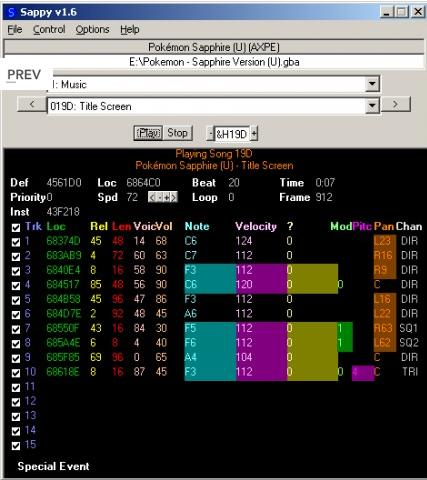

Example Audio:


In [12]:
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Screenshot of an audio track during playback in Sappy 2006. It shows 10 audio tracks defined, their associated MIDI events, memory offsets and hardware channels."
            ]
        }
    }
}
display(Image("media/sappy.jpg"), metadata=metadata)

In [ ]:
from IPython.display import Audio

# For a file on your local machine/server:
print("Example audio track extracted from ROM:")
Audio("media/song0018.mp3")

We were able to extract 80 audio tracks from the *Chobits* cartridge, such as [the one above](#sound18), using the "GBA Mus Ripper" software <cite id="wbl3c"><a href="#zotero%7C23690838%2F9U2CHNBS">(berg8793, 2020/2026)</a></cite> (Converted to MP3 from MIDI in the above figure for the sake of web compatibility). The usual Sappy application had many installation hurdles and ultimately, while it did find the Song Table (the effective "Table of Contents" of the GBA audio on the ROM), it did not find any audio tracks. Within the audio tracks we extracted, there was no dialogue to translate. This is likely due to the hardware limitations of the sound engine and the fidelity needed for voice.

You may notice that the audio is very pronounced. On a physical device, this may sound gentler as the physical speakers and circuitry would naturally muffle the sound. The digital reclaimation process also can introduce subtle differences such as encoding the tracks to different frequencies than the native device's. <cite id="sqjen"><a href="#zotero%7C23690838%2FPTC442ES">(Dortel, 2024a)</a></cite> provides a modern approach to overcoming these hurdles and extracting high-quality sound files.

The other part of the GBA device that could host audio voices is the Direct Sound component. This streams raw audio without seperation mechanisms like instrument tracks. Audio tracks may be have been seperated originally, but would have been mixed with software into a single stream before being placed in memory of the device. If one wanted to translate this audio, the entire clip would have to be re-recorded (including sound effects, background music, etc.), which makes it a very intensive undertaking.

Aside from the technical reasons for one to pass over the video and audio translation, there are also cultural preferences in the foreign consumers of Japanese media to have "Subs" instead of "Dubs". Even when Japanese media is officially translated with professional English voice actors, many enthusiasts will specifically seek out the original Japanese audio. Fans often cite reasons such as higher quality, faithfullness to the original script and the audio as it was originally envisioned <cite id="ob8ui"><a href="#zotero%7C23690838%2FLUJGQ7U4">(Pérez-González, 2006)</a></cite>. Regardless of their reasons, leaving the audio untouched can often satisfy the players who view this as an essential part of the game's atmosphere, whilst also sparing themselves the immense effort of both technically translating the audio and sourcing high quality voice talent. In an interview in 2025, CrunchyRoll (the largest anime-only streaming service) president Rahul Purini reports 48\% of U.K. anime fans watch anime subtitled. <cite id="bzzvc"><a href="#zotero%7C23690838%2F8ISK38P8">(Mullicane, 2025)</a></cite>

## Code Decompilation \& Recompilation

Usually a fan translation of a GBA game would not require any changes to the machine's assembly code, but having the ability to change it can give further flexibility to the translators. For example, the *Chobits* game text can be paged, only displaying a portion of text between the player pressing a button. This can either be due to long text strings, or for stylistic effect. This could be implemented in a dynamic way (e.g. creating a new page whenever a specific page-break character is read within a large string) or a static way (a hard-coded set of pages with separate strings), as shown visually in [the Figure on Paging methods](#paging). A static approach will constrain the translator to that static number of pages, whereas a dynamic approach will allow for more pages of text. 

In [42]:
def static_print(msg):
    msg = msg[:31] # Clip message to emulate screen limitations
    print(msg)

def dynamic_print(msg):
    for x in msg.split("¦"):
        print(x)

dialogue_1 = "Chi is staring at the TV screen again.█"
dialogue_2 = "Is she learning?█"

# The Static Paging approach has fixed entry points and does not detect marker characters.
# There is strictly a one-to-one relationship between the function calls and printing of sentences
# So the translator is restricted to that space.
print(" === Static Printing === ")
static_print(dialogue_1)
static_print(dialogue_2)

# Dynamic Paging (Marker-Based)
# The Dynamic Paging approach has a single entry points and creates additional prints when it encounters marker characters.
# By inserting additional page-break characters ('¦' representing this below), the translator can give themselves more room for translating the text.
scene_dialogue = "Chi is staring at the TV screen again.¦Is she learning?█" 
print(" === Dynamic Printing === ")
dynamic_print(scene_dialogue)

 === Static Printing === 
Chi is staring at the TV screen
Is she learning?█
 === Dynamic Printing === 
Chi is staring at the TV screen again.
Is she learning?█


By modifying the code example variables `dialogue_1`, `dialogue_2` and `scene_dialogue` to include a third message, the inherent scalability of the Dynamic approach reveals itself (And conversely, the limitations of the Static approach). Certainly, it makes the fanslator's life easier to have the Dynamic approach, but the choice of which to implement is an opaque choice by the original developers — shaped by the team's working practise, established methodologies, frameworks and of course, the inevitable pressure of deadlines to deliver functionality over longer-term structure. Technical debt is often more prevelant in the game development industry due to short development phases, short market life and a focus on maintenance post-release rather than evolution of the systems. <cite id="4m3ag"><a href="#zotero%7C23690838%2F6TXL5HZV">(Borowa et al., 2021)</a></cite><cite id="aot9l"><a href="#zotero%7C23690838%2FN39AI7XJ">(Ampatzoglou &#38; Stamelos, 2010)</a></cite>

Decompiling the ARM7TDMI machine code into human-readable source-code is a complex process, and will not be able to regenerate elements of the original game's source code that would assist in understanding it — e.g. variable names, function names and comments. Moreover, high-level language constructs such as for loops, while loops, and macro expansions can compile to functionally equivalent, but semantically different machine code. There may be hand-written assembly that was never part of a high level language, or optimizations implemented by the compiler that have unintuitive transforms. Decompilation can provide fanslators with a behaviorally equivalent of the original program, however this code may still require substantial manual interpretation to navigate.

The first step in retrieving the source code is to transform from the raw bytes contained within the ROM, to the ARM assembly instructions. The ARM7TDMI instruction set is well documented making the translation of instructions largely deterministic and straightforward. Greater difficulty lies in distinguishing code from the rest of the data within the ROM. While the ROM has a standardised declaration of the code entry point in its header, identifying additional code regions requires exploring the full natural execution of the code — including following all conditional branches, function calls, interrupts and indirect jumps. This recursive traversal and other techniques are discussed at length in <cite id="7td5b"><a href="#zotero%7C23690838%2FDS243XLL">(Pang et al., 2020)</a></cite>, and while their analysis focuses on x86/x64 platforms, many of the techniques apply equally to ARM devices such as the GBA. Indeed, some of the tools mentioned, such as Ghidra and Radare2 have been used by ROM Hackers to disassemble GBA ROMs <cite id="fy7s9"><a href="#zotero%7C23690838%2F6ZSKCQN6">(Wrongbaud, 2020)</a></cite><cite id="d8nvb"><a href="#zotero%7C23690838%2F2IAFI54C">(Megabeets, 2017)</a></cite>.

Some of these disassemblers also provide decompilation through a mixture of pattern and structural analysis. This will transform the generated assembly into a plausible high-level source-code (generally C). Many GBA games were cross-compiled with GCC for ARM distributed with the official SDK. Knowing this allows decompilers to exploit predictable GCC idioms such as calling conventions, function prologues, stack frame layouts and general code generation patterns. 

As previously mentioned, function and variable names are not recoverable, meaning that the purpose of these structures still require their behaviour to be analysed. Disassembly and decompilation tools typically assign autogenerated names through incrementing schemes independent of the game's logic (e.g. "func41", "var21"). These names provide no contextual information so investigation requires reasoning about the input, output, control flow and data access patterns of the program. We show this loss of information in a [code example below](#decompile). While this example is for x86, the same principles apply to the GBA.

In [16]:
from capstone import *

# Our original C Code looked something like this:
#
# int total_price(int price, int tax) 
# { 
#     // The final price to the consumer
#     return price + tax; 
# }
#
# But the compiled binary is just these 4 bytes:
machine_code = b"\x8d\x04\x37\xc3" 

def disassemble():
    print(f"\n[Raw Bytes]")
    print(f"Hex: {machine_code.hex(' ')}")

    print(f"\n[Disassembly to ASM]:")
    
    # Initialize Capstone for x86 64-bit
    md = Cs(CS_ARCH_X86, CS_MODE_64)
    
    for i in md.disasm(machine_code, 0x1000):
        print(f"0x{i.address:x}:\t{i.mnemonic}\t{i.op_str}")

    print("\nOBSERVATIONS:")
    print("- Comments are no longer available")
    print("- The function name is lost (Now simply a memory address and a return call 'ret')")
    print("- The context of money, tax, etc is lost.")
    print("- The addition was transformed into a LEA instruction (Load Effective Address) which adds at the same time without extra overhead.")
    print("     See also: https://dmitrysoshnikov.com/compilers/x86-generated-code-optimizations-and-tricks/ " )
    print("- Variable names 'a' and 'b' are missing, instead using register names 'rdi', 'rsi'")

disassemble()


[Raw Bytes]
Hex: 8d 04 37 c3

[Disassembly to ASM]:
0x1000:	lea	eax, [rdi + rsi]
0x1003:	ret	

OBSERVATIONS:
- Comments are no longer available
- The function name is lost (Now simply a memory address and a return call 'ret')
- The context of money, tax, etc is lost.
- The addition was transformed into a LEA instruction (Load Effective Address) which adds at the same time without extra overhead.
     See also: https://dmitrysoshnikov.com/compilers/x86-generated-code-optimizations-and-tricks/ 
- Variable names 'a' and 'b' are missing, instead using register names 'rdi', 'rsi'


Fully decompiled titles that have been converted into plausible human-readable source-code in the ROM Hacking community are rare and limited to the more popular titles for the console. These projects are generally focussed on enabling extra functionality, or entirely new unofficial games, rather than just translation.

### Data Integrity

Another reason to modify the code of the game is to circumvent data integrity checks.  While rarely used, the GBA ROM header includes a checksum byte which can be cross-checked to verify the integrity of the ROM and conditionally halt the game on a failure. This system is well known and several tools exist for ROM hackers, such as Checksuminator<cite id="rtofd"><a href="#zotero%7C23690838%2FQA9T3TH9">(Saad, n.d.)</a></cite>, to re-calculate the checksum and sometimes also replace it in the ROM. 

Understandably, most GBA ROM hacking development is performed on a PC using an emulator. Some titles embed hardware or timing probes to detect non-standard setups such as bootleg or flash cartridges and emulators. "Dragon Ball Z: The Legacy of Goku II" performs a series of reads from specific bus and I/O registers that behave differently on flash cartridges, causing the game to fail. Unlike trivial header field replacements, these modifications can require meaningful modification of game code or data to allow the game to play as expected.

In the GBA era, anti-corruption techniques were relatively simple and rarely meaningfully obstructive, whereas modern consoles incorporate far more sophisticated methods for runtime integrity and piracy prevention, increasing the complexity of fan translation and modification. However, the game industry has grown such that multi-lingual releases are much more common practice. In <cite id="lb5ui"><a href="#zotero%7C23690838%2FZCAKKSTJ">(Dranch, 2019)</a></cite>, they provide details about the languages that the games from the top 1000 best-selling titles on the Steam platform have been released in. Almost all games have an English translation, followed by roughly 70\% of the FIGS languages (French, Italian, German, Spanish), significantly higher than the rates on the GBA as seen in [the Figure below](#langcompare). The article points out that the Asian markets are now potentially underserved at only approximately 30\% of games with translations available. Interestingly this is not too different from the GBA figures, but the market in China has significantly improved. While it may seem that the need for fan translation may be relatively reduced, the absolute number of titles available today are magnitudes higher.

Loading CSVs...
Normalising & Aggregating...
Visualizing...


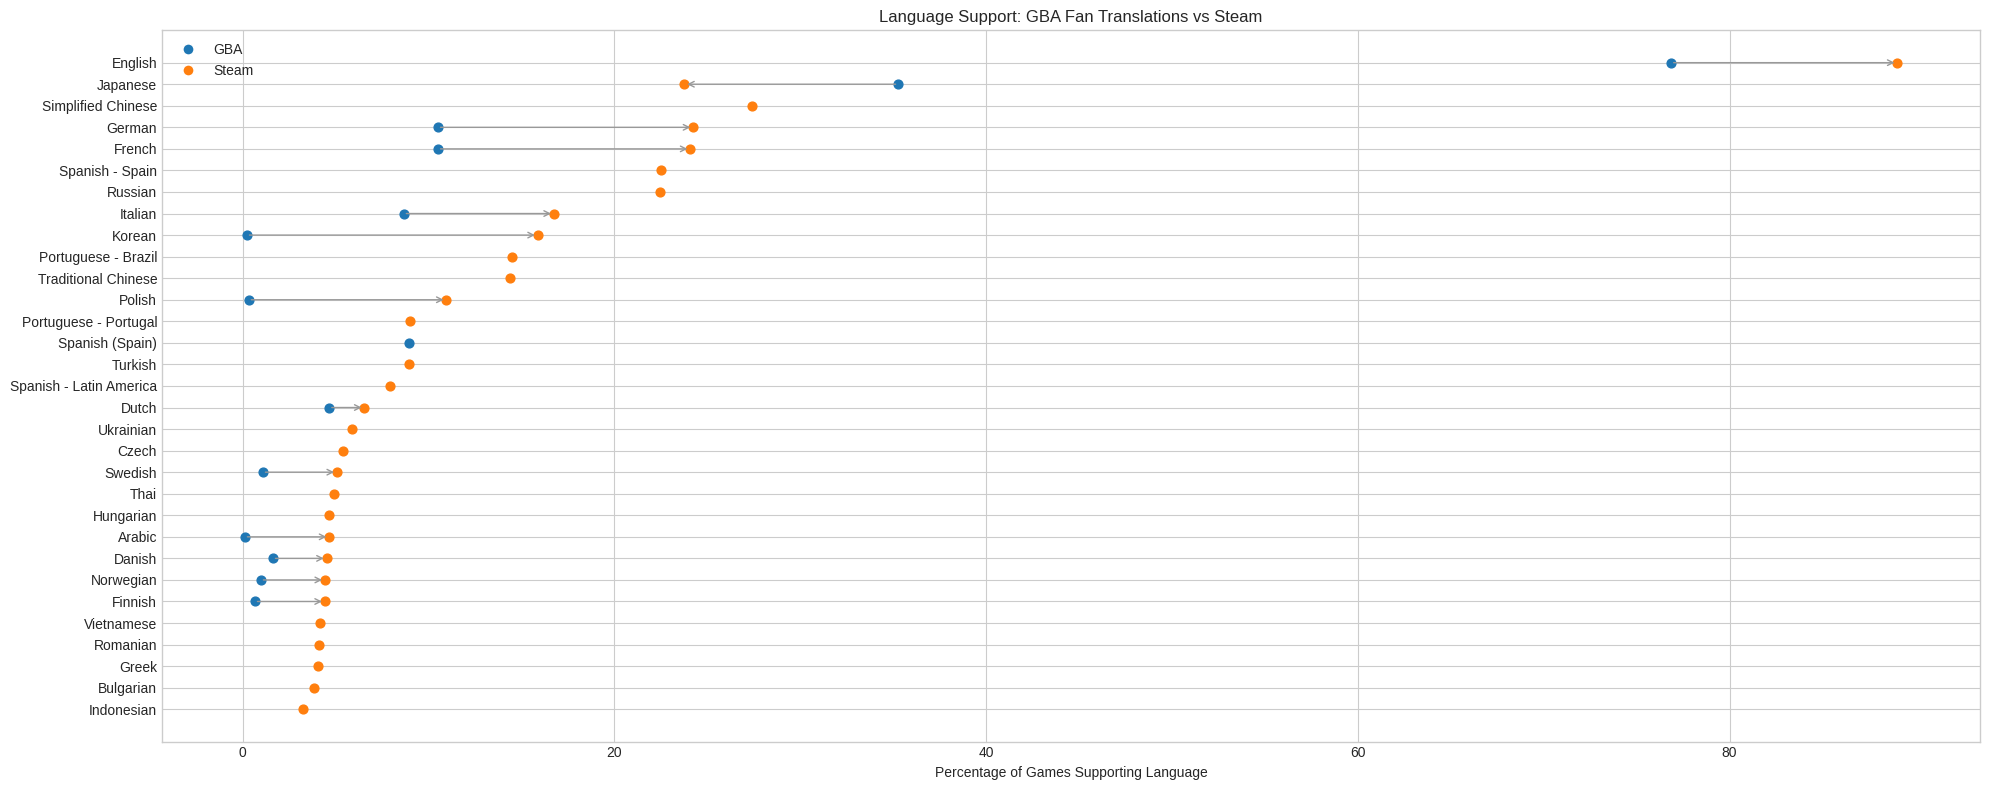

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import html

print("Loading CSVs...")

# Load GBA & Steam CSVs
df_gba = pd.read_csv("media/gba_language_distribution.csv")
df_steam = pd.read_csv("media/steam_games_clean.csv")

print("Normalising & Aggregating...")

# --- Normalize column names ---
df_gba.columns = df_gba.columns.str.strip().str.lower().str.replace(" ", "_")
df_steam.columns = df_steam.columns.str.strip().str.lower().str.replace(" ", "_")

# Rename percentage columns
df_gba = df_gba.rename(columns={"percentage_(%)": "fan_pct"})
df_steam = df_steam.rename(columns={"steam_pct": "steam_pct"})
df_steam = df_steam.rename(columns={"supported_languages": "language"})

# Steam lists multiple languages in one cell (e.g. "English, Russian"); count each language per game
steam_expanded = df_steam.assign(
    language=df_steam["language"].fillna("").astype(str).str.split(",")
).explode("language", ignore_index=True)
steam_expanded["language"] = steam_expanded["language"].str.strip()
steam_expanded = steam_expanded[steam_expanded["language"].ne("")]

# --- Aggregate Steam data by language ---
steam_lang_pct = (
    steam_expanded.groupby("language")
    .size()
    .reset_index(name="steam_count")
)

total_steam_games = len(df_steam)
steam_lang_pct["steam_pct"] = steam_lang_pct["steam_count"] / total_steam_games * 100
steam_lang_pct = steam_lang_pct[["language", "steam_pct"]]

# --- Merge GBA and Steam ---
merged = pd.merge(df_gba, steam_lang_pct, on="language", how="outer")

# --- Sort by max value for readability ---
merged["sort_val"] = merged[["fan_pct", "steam_pct"]].max(axis=1)
merged = merged.sort_values("sort_val")

# Filtering out very low percentage languages
minimal_threshold = 2
merged = merged[(merged["fan_pct"].notna()) | (merged["steam_pct"].notna())]
merged = merged[
    (merged["fan_pct"] > minimal_threshold) | (merged["steam_pct"] > minimal_threshold)
]

print("Visualizing...")

# --- Colors ---
gba_color = "#1f77b4"
steam_color = "#ff7f0e"
line_color = "#999999"

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 8))
y_pos = np.arange(len(merged))

for i, row in enumerate(merged.itertuples(index=False)):
    x0 = row.fan_pct
    x1 = row.steam_pct

    # Arrow between both points when both are finite percentages
    if pd.notna(x0) and pd.notna(x1) and x0 != x1:
        ax.annotate(
            "",
            xy=(x1, i),
            xytext=(x0, i),
            arrowprops=dict(arrowstyle="->", color=line_color, lw=1),
        )

    # Dots where we have a value
    if pd.notna(x0):
        ax.scatter(x0, i, color=gba_color, s=40)
    if pd.notna(x1):
        ax.scatter(x1, i, color=steam_color, s=40)

# --- Labels ---
ax.set_yticks(y_pos)
ax.set_yticklabels(merged["language"])
ax.set_xlabel("Percentage of Games Supporting Language")
ax.set_title("Language Support: GBA Fan Translations vs Steam")

# --- Ensure lone points are visible ---
all_values = list(merged["fan_pct"].dropna()) + list(merged["steam_pct"].dropna())

xmin = min(all_values) if all_values else 0
xmax = max(all_values) if all_values else 1
padding = (xmax - xmin) * 0.05 if xmax != xmin else 1
ax.set_xlim(xmin - padding, xmax + padding)

# --- Legend ---
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='GBA',
           markerfacecolor=gba_color, markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Steam',
           markerfacecolor=steam_color, markersize=8)
]

ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

## Releasing

Fan translation projects are typically distributed as "diff" or "patch" files that are intended to be applied to player's own game copies. These patch files use formats niche to the hobby such as the International Patch System (IPS), UPS (Universal Patch System) and BPS (Best Patch System) which was created to address limitations of the earlier systems. They operate on binary files in a similar, but simpler, manner to the xdelta tool which is used for similar purposes outside the hobby for binary file comparison <cite id="n9mpf"><a href="#zotero%7C23690838%2FJ2V2DHGJ">(ROMhacking.net, n.d.)</a></cite><cite id="p5sjf"><a href="#zotero%7C23690838%2F5GEAI8EV">(byuu, 2006)</a></cite> <cite id="x0gmb"><a href="#zotero%7C23690838%2F5GEAI8EV">(byuu, 2006)</a></cite>.

*Chobits* had only one physical cartridge release, so a single patch file would be easy and sufficient to produce. However, for games with several releases (e.g. official translations, content revisions, publisher changes, limited editions, etc), the offsets within the ROM may have changed, causing a patch file to corrupt these files. Therefore, fan translators must either produce multiple patch file releases, or standardise on a specific edition. As many changes to the ROM may not be automated, fan translators tend to favour the latter approach.

# Analysis

The emerging insight in this study is that there are many technical barriers for unofficial fan translations, beyond the typical linguistic complexities one might encounter translating other media. The GBA platform is an older system, and even with the advantage of being simpler technology and with years of community development, many aspects remain tedious, manual and sometimes, ultimately, impenetrable.

## Practical Approaches

The main purpose of fan translation is to make media accessible to new audiences. With that in mind, certain aspects of a GBA game are more influential to the translated release than others. We offer a broad cross-compare the "return on development" for several features in  [the below table](#table-ROI). Clearly, the main game text and dialogue is the heart of the visual novel and without it, the game will be difficult to enjoy by someone who does not understand the original language. There are two approaches, as discussed earlier in [the Text Translation Section](#text-translation) — in-place text translation, which, while easier, severely limits the translator to the original text size. The other approach, in which the game's pointers are changed to newly allocated memory locations, while requiring more technical knowledge, gives significantly more freedom to the translator. This could be the difference between the translation freedom of two alphanumeric characters for a piece of dialogue, or thirty-two.

In our experience with the *Chobits* case study, this is likely enough for all but the toughest of translation scenarios. A translator may have to still use sub-par translations due to limited space, but it is enough to communicate the significant intent of the text.

Many game UI components in the *Chobits* game were rendered as graphical assets. However, the function of these buttons, tabs, and other interactive components could generally be derived from either their visual appearance (e.g. tabs for toggling between different character sets (e.g. lower/upper case) or text accompanied by a familiar icon like a floppy disc for saving the game) or trial-and-error function (e.g. "Yes" which advances the game, "No" which returns the player to a previous screen). While functional, it is not an ideal gaming experience to have the player decypher and intuit parts of the game themselves, therefore adding translations for these components can be valuable. However, this does require additional skill, both artistic and technical, and the difficulty of doing so increases should the translator encounter a non-trivial encoding system for the images, such as the ones we encountered which led to us using *Love Hina* as a stand-in.

Other aspects of the translation process are often too cumbersome to implement unless a translator is particularly motivated, skilled and patient. Video and Audio replacement requires much more than simple data swapping. It requires videography and audiography skills, bit-rate re-encoding, timing reconciliation, compression knowledge to name some technical limits, not to mention voice acting talent. The technical process of decompilation of the codebase is possible with modern tooling, but interpretting the generated source is still a gargantuan effort. Realistically, the effort required is disproportionate to the payoff of simply longer translation strings. However, if a project aim is to add additional functionality to a game, above language replacement, this would be an essential requirement.

|  | Low Impact | Medium Impact | High Impact |
|----------------------|------------|---------------|-------------|
| **High Difficulty**     | Video & Audio Replacement   | Dynamic Page Management | Reverse Engineering Propietary Compression |
| **Medium Difficulty**      | Graphical System Text (e.g. "Loading...")   | Graphical UI Components  | Memory/Pointer Table Reallocation |
| **Low Difficulty**      | ROM Header Data     | In-place String Replacement  |  —  |

The [table presented above](#matrix) is inherently subjective, but is presented not as a rule, but as a helpful guideline summary of the qualities of the aspects of translating GBA titles. Difficulty is judged based on the required prior knowledge of the fanslator as well as the current availability of tooling or documentation. The "Impact" axis is more aligned to the expected functional result on the translation. For example as was explained previously, textual content trumps audio/visual content for most titles. Logically, a project would gain most benefit starting with implementing features from the bottom-left and moving towards the top-right as development progresses.

## Pipeline Improvements

### Reproducible Workflow

A risk for the inexperienced translator is to rely on incremental manual changes to the base ROM. A developer may overwrite critical data in a future "chapter" of the game, while only testing the first one. Indeed, this behaviour is indirectly encouraged by the prevelance of GUI tools over commandline ones. These silent bugs can remain hidden until late in development, causing significant reimplementation work.

To mitigate this, it is advisable to have a repeatable pipeline of scripts and tool calls so that the ROM can be rebuilt from a "clean" state each time. If a bug is encountered later on, one can disable some of the steps in a triage attempt. This becomes more critical as a translation effort becomes more complex and changes to the ROM are committed with less confidence (e.g. modifications after corruption mapping). For instance, in our effort to translate the *Chobits* game, we created two scripts for text replacement. One to detect and extract game strings from the ROM into a csv file, and another to process an annotated version of that csv with our translation replacements. This allows rolling-back of any individual action should we later encounter a corruption.

Depending on the complexity of the translation, development teams may feel that the overheads of creating a rigid pipeline may outweigh its benefits. For example, some ROM hacking tools allow in-place "drawing" over the tiled graphics, without exposing the artist to palette indexing, non-contiguous memory or the command-line. It must also be considered that some who enter the realm of ROM hacking are not programmers and interact with the hobby through community provided tools only.

A reproducible system also allows for the production of multiple patch files for different cartridge targets. In a incremental development, the process may become very attached to one particular cartridge variant, leading to total dependence on that target cartridge, or releases of sizeable patch files which effectively overwrite one ROM with another, stripping regional or revision-specific characteristics.

### Testing

In most software projects, testing is a standard practice. However, the options for ROM hackers are limited. While decompiled or original games can take advantage of existing C testing suites such as GoogleTest <cite id="dpkr5"><a href="#zotero%7C23690838%2FCST74MPW">(Google, 2026)</a></cite> or create their own, translators operating solely on the compiled ROM have fewer such facilities. 

Emulators often provide the ability to save full-system snapshots (known as "save states") — copies of the system's volatile memory (RAM, VRAM, registers) at a precise moment in time — allowing translators to immediately "jump" to specific scenes or scenarios within the game ROM (e.g. the start of each chapter). This allows more granular "jumping" than traditional game saving provided by the cartridge itself. This is immensely useful for the hobbyist translator for saving time to verify their translations have loaded in correctly, but it must be mentioned that it is not infallible — because the save state preserves the exact memory conditions of the moment it was created, it can mask issues that only occur during a contiguous play session, such as memory leaks or pointer corruption. It also does not verify that the state itself is reachable naturally by the preceding code should it be later edited.

Other than manual validation, some emulators like mgba <cite id="56hhc"><a href="#zotero%7C23690838%2F5WE9PFH3">(Pfau, 2013)</a></cite> offer scripting APIs that facilitate memory inspection and automated gamepad input. This may be useful for confirming that translations have been written correctly to the ROM, but despite the helpful APIs, for many cases it may be easier to perform static test externally than dynamically through the API — for example, validating all strings are of a certain length before writing them to ROM, than to inspect a specific location in VRAM for overflow. That being said, the game strings in *Chobits* are generally complete and do not include variable injection (e.g. where "You found a \[ITEM\]" is expanded during execution and the string length is not known ahead of time), which may be better suited to a dynamic testing approach.

Ultimately, while sophisticated dynamic analysis is available, the fact that most information is either known ahead of time, or can be investigated beforehand means that validation of the modification scripts, their inputs and their outputs, is a more practical approach barring particularly complex transformations.

### Abstraction

While translators may be motivated to the hobby by their interest in a particular game title, generic community tools are of large benefit to the hobby as a whole, and contributions back into this sphere should be encouraged. Many titles require the same type of operations, just the data is different. The game "*Love Hina*", as mentioned in [Image Translation](#image-translation), is a visual novel by the same development company as *Chobits* and many required operations for data extraction and replacement would surely be common between them. 

It has also been mentioned that translating GBA games is a hobby which requires many different skills.  Abstracting data into common formats, such as CSV or XLSX can make it easier to recruit translators to assist with the project as they are more likely to be familiar with spreadsheets than with command-line interfaces. It also opens new sources of assistance, for example with crowd-sourced websites such as OneSky <cite id="ciiy5"><a href="#zotero%7C23690838%2FEN4PSJM3">(OneSky, 2026)</a></cite>, or machine translation through the use of large language models (LLMs). Furthermore, adopting internationalisation standards — such as those defined by the W3C's (i18n) <cite id="0gyrf"><a href="#zotero%7C23690838%2FI5JF8AEM">(W3C, 2026)</a></cite>, projects can facilitate other translators to add their own language contributions with limited technical knowledge. Thus, a single technical effort can enable localisations in multiple target languages simultaneously, even if not with immediate effect. This is a particularly salient improvement as each translation effort generally results in a single language translation on release, meaning that many duplicate efforts must be made to cover a wide set of languages.


During the course of this project, a machine-translated fanslation of *Chobits* was released (unaffiliated with this work or its author) <cite id="n7jde"><a href="#zotero%7C23690838%2FXVQ56289">(Gopicolo, 2025)</a></cite>. While this release's quality of translation is middling to poor due to lack of contextual information, it does show how such technologies can provide quick initial implementations in which human refinement can be built on top of.

### Alternative Solution — Real-Time Screen Translation

In addition to ROM modification, recent advancements in Optical Character Recognition (OCR) and Computer Vision have introduced the possibilty of "on-the-fly" machine-translated systems as a low-barrier alternative to manual translation. The RetroArch <cite id="6b7tr"><a href="#zotero%7C23690838%2FBFJRLXGQ">(Libretro Team, 2024)</a></cite> platform can capture a game's frame buffer, extract the text, process it through a machine-learning system and overlay the resultant translated text atop the game.

While these tools offer immediate translation, they suffer from the same contextual isolation issues that a blind machine-translation of a game's script would, as well as the OCR technology as another potentional source of errors. However, recent benchmarks of OCR accuracy have undergone significant iterative improvement (Comprehensive evaluations in 2025 showed that average OCR accuracy for printed text has reached 98.5\%–99.5\%, up from roughly 95\% in 2020 <cite id="x1pcg"><a href="#zotero%7C23690838%2FXM6IZVF2">(Sparkco AI, 2025)</a></cite>) and suggest that the gap between manually patched games and automated overlays may narrow, though lack of access to the internal state of the game  remains a limitation. In the Figure below, we show a screenshot of the RetroArch tool as applied to a scene in the game "Shin Megami Tensei — Devil Summoner" for the Sega Saturn platform. The original text reads "わたしにも、何か頼んでよ。 自分でたのめば? オレンジジュースにする?". While the machine translation has understood the literal meaning of the words, it has missed the social context of the scene (The character Kumiko has just arrived at the bar to meet the protagonist) and the sentences are disjoint. A better translation might be "Would you order something for me too? Orange Juice?"

In [19]:
from IPython.display import display, HTML

meta = {
    "jdh": {
        "module": "object",
        "object": {
            "type": "image",
            "source": ["Screenshots from user Nyarly's 'How to Play Most Japanese Megami Tensei Games in English with Machine Translations' on YouTube."]
            # https://www.youtube.com/watch?v=oGNdDLla8QY
        }
    }
}

display(HTML(f"""
<div style="display: flex; justify-content: center; align-items: center;">
    <div style="margin: 5px;">
        <img src="media/retroarch_original.png" width="400">
        <p style="text-align: center;">Original</p>
    </div>
    <div style="margin: 5px;">
        <img src="media/retroarch_translation.png" width="400">
        <p style="text-align: center;">Translated</p>
    </div>
</div>
"""), metadata=meta)

# Conclusion

In this paper, we've detailed the development of a fan translation of the Game Boy Advance title *Chobits: Atashi Dake no Hito*. With limited existing academic research on the technical aspects of fan translation, this paper provides a deep overview of the challenges that these hobbyists face and the approaches they take against them. 

Through our case study, we show the multi-layered and complex nature of translating such a game. Requiring hobbyists to possess technical, linguistic and artistic skills of various depth. We show the raw text translation techniques required to perform a basic, functional localised version of the game, but discuss the process and feasibilities of more complex translations such as image asset changes. Code modifications, audio and video modifications are typically poor return of time investment unless such a feature is critical to a project.

The case study was not without challenges. We were unable to discern the encoding of certain key UI assets within the game and had to examine another game (*Love Hina Advance*) to demonstrate the concept, demonstrating that even though guidelines can be given, ultimately the game cartridge is a compiled artefact with little insight on its original source-code state or implementation design. It is upon the back of many community guides, tools and insights that such a hobby can exist.

Along with our study, we provide a set of practical recommendations for those undergoing similar efforts. In particular, we encourage the use of clean, reproducible pipelines over incremental manual modifications to improve reproducibility, target multiple cartridges, and recover from silent data corruption earlier in development. We advise on the practical aspects to focus development on, and which to avoid. We also advocate the further abstraction of the tools and processes used in fan translation — opening the hobby to more languages and contributors to further the goal of making the games accessible to new fans.

## Ethics

As has been described in the [Introduction](#introduction), this research focuses exclusively on the methodology of reverse engineering and translation techniques for the GBA of which knowledge is transferrable to other games and other platforms. 

The artifacts of this research have not been published as a traditional fan translation may have been. The author is neither trained sufficiently in the field of translation, nor do they wish to extend this work beyond the bounds of academic research, nor do they wish to engage with the predescribed associated murky legalities of publishing such a work. No aspects of the game aside from what has been presented within this paper has, or will be made available to the public from this work.

## Future Work

While the specific development and publication of the *Chobits* translation will not be continued, the reflections within this article may provide advice for future advancements of community tooling. One potential area for investigation is increasing the effectiveness of LLMs to automate game translations by programmatically providing required context and localisation advice.

Infrastructural improvements would be a welcome addition. In particular, testing, as cycle time for a project can be slow due to the repeated manual checking of temporal string placement and visual defects. Further efforts in enabling others in their localisation efforts through internationalisation frameworks and cleanly interoperable modular extraction/replacement tools are essential for modernising the field and enabling the main objective of the activity — to allow new players to play games previously inaccessible to them.

Overall, fan translations have been neglected in technical research, despite the inherently interesting space it occupies — a place on the fringes of legality, driven by a hacking culture and outside mainstream tooling and formal structures. We hope this study will inspire others to perform similar research.

## Glossary

- **ASCII**: A simple 8-bit text encoding for roman characters, numerals and other common characters.
- **BIOS**: Basic Input Output System. Firmware on a computer’s motherboard that initializes hardware during startup and loads the operating system
- **CV**: Computer Vision
- **CSV**: Comma Seperated Values. Commonly used as a format for spreadsheets or tabular data.
- **DMA**: Direct Memory Access. A hardware memory transfer system 
- **Dubs**: Dubbing. Recording audio over an existing video.
- **HUD**: Heads-Up Display
- **GBA**: Game Boy Advance
- **GCC**: GNU C Compiler
- **GUI**: Graphical User Interface
- **IGDB**: Internet Game Database
- **IP**: Intellectual Property
- **LLM**: Large Language Model. A type of Neural Network
- **OCR**: Optical Character Recognition
- **PALRAM**: Palette RAM. An area in the GBA's memory space to load palettes
- **PCM**: Pulse Code Modulation
- **RAM**: Random Access Memory. Read-Write Memory of the GBA
- **ROM**: Read-Only Memory (The contents of the game cartridge)
- **SDK**: Software Development Kit
- **SHIFT-JIS**: A text encoding often used for Japanese text
- **Subs**: Subtitles
- **VRAM**: Video Random Access Memory
- **W3C**: World Wide Web Consortium
- **XLSX**: A spreadsheet format used in Microsoft Excel